# Shape noise models compared on the noise maps

Visual and quantitative sanity check of the shape noise models of `observation.forward_model_cosmogrid`, generated as
**noise only** maps for a single mock. Where `count_maps_desy3.ipynb` stops at the source galaxy counts, this notebook
picks the chain up one step later, at the `wl_gamma` maps that `lensing.noise_gen` builds from those counts — which is
what the network actually sees.

## The four arms

The model is set by the `shape_noise` block of the config, parsed by `files.get_shape_noise`:

| arm | `method` | `survey_systematics` | what it is |
|---|---|---|---|
| `in_place` | `in_place` | — | randomly rotate the real DES Y3 catalog galaxies in place. Real survey inhomogeneity, but **no** correlation with the simulation LSS |
| `gatti` | `gatti` | — | [Gatti et al. 2023](https://arxiv.org/abs/2307.13860): real catalog positions with the noise *modulated* by the simulation LSS, $f = 1/\sqrt{1 + b_{sc}\delta}$. Sits between the two extremes |
| `count_clean` | `count` | `False` | source counts drawn *entirely* from the simulation density. LSS-source correlation, but the real survey inhomogeneity is thrown away |
| `count_contam` | `count` | `True` | the same, with the DES Y3 imaging systematics reimposed on the model density. **This is what v18 runs** |

The last two are the pair of `count_maps_desy3.ipynb`, each at its own fitted bias from `bias_fit_desy3.ipynb`.

## Why the fourth arm matters

`in_place` and `gatti` place noise at **real catalog positions**, so their noise already carries the true DES Y3
imaging systematics for free. The `count` method throws those positions away and rebuilds the counts from the
simulation, which is exactly why the imprint has to be put back by hand. That gives the last section a target rather
than just a comparison: measured against the contamination map, `in_place` is the truth, `count_clean` should be flat
because the imprint was lost, and `count_contam` should recover the `in_place` slope.

## Note on the port

This notebook used to set `conf[...]["lensing"]["source_clustering"] = "rotate" | "fixed" | "gatti"`. That key no
longer exists anywhere in `msfm` — it was replaced by the nested `shape_noise` block — so the old version would
silently have compared three identical maps. Two further traps are worth knowing:

- `forward_model_cosmogrid` **silently switches `method` to `count`** when `tomo_bg_metacal` is passed and the method
  is not `gatti` (historical behavior). `in_place` therefore has to be called without a bias.
- `files.get_shape_noise` validates `fixed_bsc` for `gatti` *before* `tomo_bg_metacal` can override it, so the block
  needs a `fixed_bsc` entry even when the call supplies the bias.

**Run this on a compute node in the `torch_env` kernel** (`uenv start --view=default pytorch/v2.9.1:v2`, then
`source ~/dlss/torch_env/bin/activate`). Five forward model evaluations, a few minutes.

In [1]:
import copy, os

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

from msfm.utils import observation, files, filenames, lensing, imports

hp = imports.import_healpy()

In [2]:
repo_dir = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model"
conf = files.load_config(os.path.join(repo_dir, "configs/v18/baseline.yaml"))

# fiducial CosmoGrid v11desy3 projection on Clariden, the same maps count_maps_desy3.ipynb reads
map_dir = "/iopsstor/scratch/cscs/athomsen/CosmoGrid/v11desy3/bary/fiducial/cosmo_fiducial/perm_0000"

n_side = conf["analysis"]["n_side"]
n_pix = hp.nside2npix(n_side)
metacal_bins = conf["survey"]["metacal"]["z_bins"]
n_z = len(metacal_bins)

# tomographic bin to inspect. The last one is where the contamination is largest (22% per pixel against 12% shot
# noise), so it is where the survey systematics arm can be told apart from the others at all
i_z = 3
noise_seed = 12

# per cosmology source clustering biases of the two arms of bias_fit_desy3.ipynb, at the fiducial cosmology. They are
# passed to the forward model explicitly, so the config's own metacal_bias table is never read here and the two count
# arms cannot silently end up on the same bias
bias_files = {"clean": "data/metacal_biases_desy3_v2.h5", "contam": "data/metacal_biases_desy3_v2_sys.h5"}
b_fit = {}
for name, path in bias_files.items():
    with h5py.File(os.path.join(repo_dir, path), "r") as f:
        b_fit[name] = f["fiducial"][:]
    print(f"b_gs ({name:6s}) = {np.round(b_fit[name], 3)}")

# base survey patch (i_patch = 0), full sky RING indices. The contamination map is delivered in this frame
_, patches_pix_dict, _, _ = files.load_pixel_file(conf)
patch_pix = patches_pix_dict["metacal"][i_z][0]
assert np.array_equal(patch_pix, patches_pix_dict["metacal"][0][0]), "the base patch differs between metacal bins"
print(f"\ninspecting {metacal_bins[i_z]}, base patch of {len(patch_pix)} pixels, noise seed {noise_seed}")

b_gs (clean ) = [0.988 1.395 1.811 3.058]
b_gs (contam) = [0.957 1.312 1.655 1.981]

inspecting metacal4, base patch of 318616 pixels, noise seed 12


In [3]:
def run(method, bias="fixed", survey_systematics=False, b_sc=None, seed=noise_seed):
    """Noise only weak lensing gamma maps of one shape noise model.

    Args:
        method (str): "in_place", "gatti" or "count", see files.get_shape_noise.
        bias (str, optional): "fixed" or "prior", ignored for method "in_place". Defaults to "fixed".
        survey_systematics (bool, optional): Whether to imprint the DES Y3 imaging systematics on the model source
            density. Only defined for method "count". Defaults to False.
        b_sc (array-like, optional): Per metacal bin source clustering bias, passed as tomo_bg_metacal. Must be left
            None for "in_place", which the forward model would otherwise silently switch to "count".
        seed (int, optional): Noise seed. Defaults to noise_seed.

    Returns:
        np.ndarray: (n_pix, n_z, 2) full sky gamma maps, only the base patch populated.
    """
    c = copy.deepcopy(conf)
    shape_noise = {"method": method, "bias": bias, "survey_systematics": survey_systematics}
    if method == "gatti":
        # validated before tomo_bg_metacal can override it, so it has to be present and of the right length
        shape_noise["fixed_bsc"] = [1.0] * n_z
    c["analysis"]["modelling"]["lensing"]["shape_noise"] = shape_noise

    wl_gamma, _ = observation.forward_model_cosmogrid(
        map_dir,
        conf=c,
        noisy=True,
        noise_only=True,
        with_lensing=True,
        with_clustering=False,
        tomo_bg_metacal=b_sc,
        noise_seed=seed,
    )

    return wl_gamma


arms = {
    "in_place": dict(method="in_place"),
    "gatti": dict(method="gatti", b_sc=b_fit["clean"]),
    "count_clean": dict(method="count", b_sc=b_fit["clean"]),
    "count_contam": dict(method="count", b_sc=b_fit["contam"], survey_systematics=True),
}
g = {name: run(**kwargs) for name, kwargs in arms.items()}


def noise_power(gamma, pix=patch_pix):
    """Per pixel shape noise power g1^2 + g2^2 of the inspected tomographic bin."""
    m = gamma[:, i_z, :] if pix is None else gamma[pix, i_z, :]

    return m[..., 0] ** 2 + m[..., 1] ** 2


# the count arms populate every footprint pixel, the in place ones only pixels that hold real catalog galaxies
for name, gamma in g.items():
    power = noise_power(gamma)
    occupied = power != 0
    print(f"{name:13s}: {100 * occupied.mean():5.1f}% of the base patch populated, "
          f"mean noise power {power[occupied].mean():.3e}")

26-08-04 10:42:24 observation. INF   Loading the full-sky map from /iopsstor/scratch/cscs/athomsen/CosmoGrid/v11desy3/bary/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_v11dmb.h5 
26-08-04 10:42:24 observation. INF   Starting with the weak lensing map 
26-08-04 10:42:53 observation. INF   Using tomo_Aia=[0.35989797 0.44188944 0.55791044 0.6524075 ] from the config 
26-08-04 10:42:53 observation. INF   Using bta=None from the function call 
26-08-04 10:42:53 observation. INF   Using standard NLA 
26-08-04 10:42:53 observation. INF   Rotating galaxies in place for shape noise 
26-08-04 10:42:55     files.py INF   Loaded the noise file 
26-08-04 10:43:28 observation. INF   Finished weak lensing after 0:01:04.86 
26-08-04 10:43:29 observation. INF   Loading the full-sky map from /iopsstor/scratch/cscs/athomsen/CosmoGrid/v11desy3/bary/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_v11dmb.h5 
26-08-04 10:43:29 observation. INF   Starting with the weak lensing map 
26-08-04

### The no-op check, and what it depends on

At $b_{sc} = 0$ the gatti modulation $f = 1/\sqrt{1 + b_{sc}\delta}$ is exactly 1, so `gatti` should reduce to
`in_place`. Whether it reduces to it *exactly* depends on the source clustering **calibration**, which is
`files.read_sc_calibration` evaluated at $b_{sc} = 0$ rather than switched off:

- with **no** `sc_calibration` file configured — the v18 case — the calibration is the no-op $(1, 1, 0)$ and the two
  maps agree bit for bit,
- with a calibration file configured, as under the old v16 config this notebook used to load, the fits return a
  non-unit `corr_variance` and `A_corr` at zero and what survives is a **constant rescaling**
  $1/\sqrt{A_\mathrm{corr}\,\mathrm{corr\_variance}}$ per tomographic bin. The old version of this notebook printed
  that as a bare `False` without explaining it.

The check below therefore tests the property that holds in both cases: the ratio of the two maps is *constant over the
footprint*, i.e. the modulation changes the noise amplitude but not its spatial pattern. It is skipped with a message
if `coeff_kurtosis` is nonzero, which would add a genuine per pixel factor through the reference variance map.

In [4]:
g_gatti_b0 = run(method="gatti", b_sc=np.zeros(n_z))

corr_variance, A_corr, coeff_kurtosis = files.read_sc_calibration(conf, np.zeros(n_z))[i_z]
expected = 1 / np.sqrt(A_corr * corr_variance)
print(f"calibration at b_sc = 0: corr_variance {corr_variance:.4f}, A_corr {A_corr:.4f}, "
      f"coeff_kurtosis {coeff_kurtosis:.4g}")

# |mod| = sqrt(power ratio), since the modulation multiplies both shear components
power_ref = noise_power(g["in_place"])
occupied = power_ref != 0
mod = np.sqrt(noise_power(g_gatti_b0)[occupied] / power_ref[occupied])

print(f"gatti(b_sc = 0) / in_place: mean {mod.mean():.5f}, relative scatter {mod.std() / mod.mean():.2e}")
print(f"expected constant rescaling 1 / sqrt(A_corr * corr_variance) = {expected:.5f}")
print("plain equality (what the old notebook checked):", np.allclose(g_gatti_b0, g["in_place"]))

if coeff_kurtosis == 0:
    assert np.allclose(mod, mod.mean(), rtol=1e-4), "gatti at b_sc = 0 is not a constant rescaling of in_place"
    assert np.isclose(mod.mean(), expected, rtol=1e-3), "the rescaling is not the b_sc = 0 calibration"
    print("\nthe modulation is a pure constant, as it should be at b_sc = 0")
else:
    print(f"\ncoeff_kurtosis = {coeff_kurtosis:.4g} is nonzero, so a per pixel term is expected on top of the "
          "constant; assert skipped")

26-08-04 10:45:12 observation. INF   Loading the full-sky map from /iopsstor/scratch/cscs/athomsen/CosmoGrid/v11desy3/bary/fiducial/cosmo_fiducial/perm_0000/projected_probes_maps_v11dmb.h5 
26-08-04 10:45:12 observation. INF   Starting with the weak lensing map 
26-08-04 10:45:41 observation. INF   Using tomo_Aia=[0.35989797 0.44188944 0.55791044 0.6524075 ] from the config 
26-08-04 10:45:41 observation. INF   Using bta=None from the function call 
26-08-04 10:45:41 observation. INF   Using standard NLA 
26-08-04 10:45:41 observation. INF   Gatti source-clustering: density-modulated rotate-in-place shape noise 
26-08-04 10:45:41 observation. INF   Using b_sc=[0. 0. 0. 0.] from the function call (tomo_bg_metacal) 
26-08-04 10:45:41     files.py WAR   No sc_calibration file configured, using no-op source-clustering calibration 
26-08-04 10:45:43     files.py INF   Loaded the noise file 
26-08-04 10:45:46 observation. INF   Finished weak lensing after 0:00:33.87 
26-08-04 10:45:46     fi

# The two reference fields

The noise can be modulated by two things: the simulation density contrast $\delta$, which only the source clustering
arms know about, and the DES Y3 contamination $C = \langle 1/W \rangle$, which only `count_contam` imposes explicitly
and which `in_place` and `gatti` carry implicitly through the real catalog positions.

Pixel averaged shear noise scales as one over the number of galaxies in the pixel, so the noise power should track
$f^2 = 1/(1 + b_{sc}\delta)$ and $1/C$ respectively — both are plotted in that form below. The two fields are
statistically independent, one being a property of the survey and the other a realization of the simulation, which is
what lets the two diagnostics of the last section separate cleanly.

In [5]:
# simulation source bin density contrast, built exactly like the count and gatti branches (full sky RING)
map_file = filenames.get_filename_full_maps(map_dir, with_bary=conf["analysis"]["modelling"]["baryonified"])
with h5py.File(map_file, "r") as f:
    dg = np.stack([hp.ud_grade(f[f"map/dg/{zb}"][:], n_side) for zb in metacal_bins], axis=-1)

delta = (dg - np.mean(dg, axis=0)) / np.mean(dg, axis=0)
f_mod = lensing.source_clustering_factor(delta[:, i_z], b_fit["clean"][i_z])

# the DES Y3 imaging systematics that count_contam imprints, 1 (no correction) outside of the base patch
contamination = files.get_metacal_systematics(conf, full_sky=True)

print(f"delta         std {delta[patch_pix, i_z].std():.4f}")
print(f"contamination std {contamination[patch_pix, i_z].std():.4f}")
print("correlation of the two over the base patch:",
      round(float(np.corrcoef(delta[patch_pix, i_z], contamination[patch_pix, i_z])[0, 1]), 4))

delta         std 0.1009
contamination std 0.2220
correlation of the two over the base patch: 0.0087


# Local noise power maps

A single noise realization looks like static everywhere, so the per pixel noise power $g_1^2 + g_2^2$ is downgraded to
a coarse resolution to reveal its *envelope*. Averaging is over the populated pixels only, so that the sparsely
covered edge of the catalog footprint is not mistaken for a region of low noise.

The second figure is the two reference fields at the same resolution. `gatti` and the `count` arms should be
anti-images of $\delta$ (they follow $f^2$), and `count_contam` should carry $1/C$ on top of that.

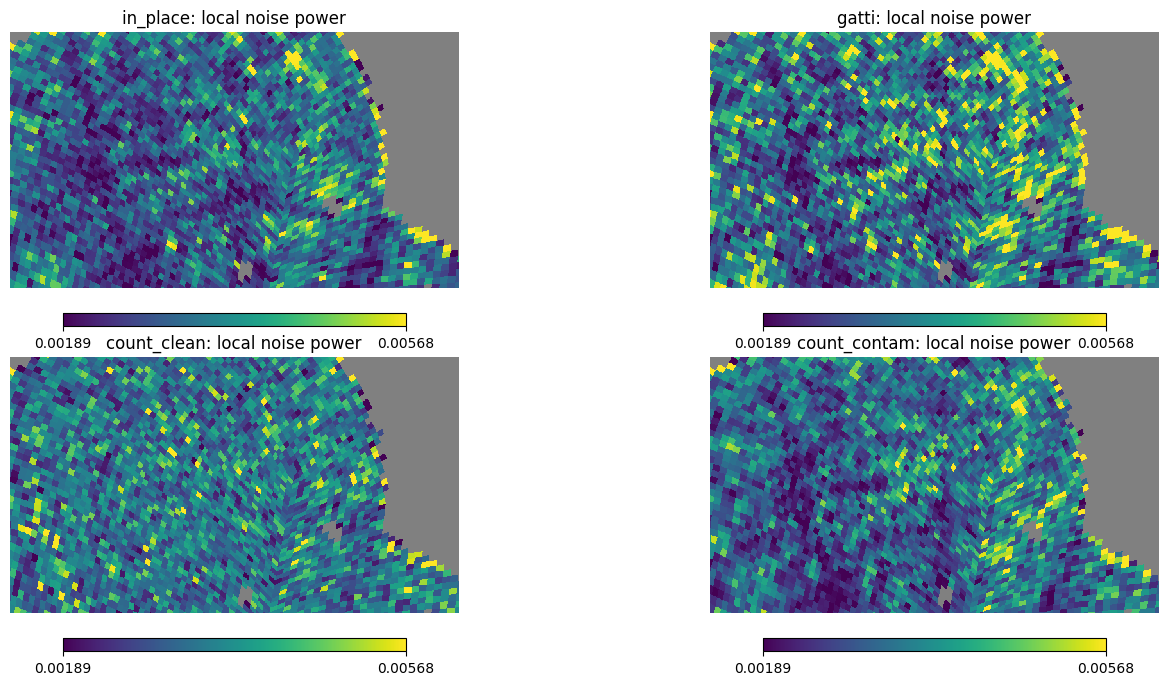

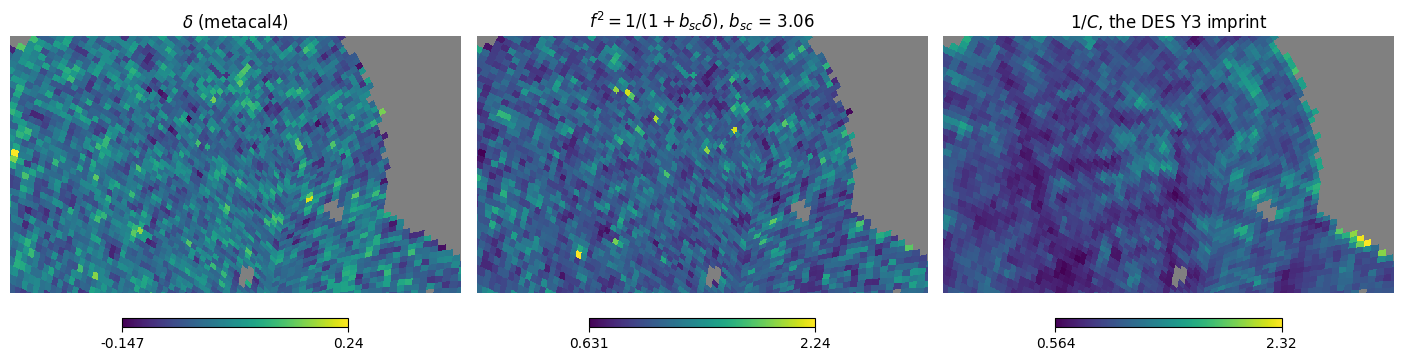

In [6]:
nside_low = 64


def low_res(values, pix=None, nside_low=nside_low):
    """Downgrade a map to nside_low, averaging over the populated pixels only.

    Args:
        values (np.ndarray): Either a full sky map (pix None, unpopulated pixels being exactly zero) or the values of
            the pixels given by pix.
        pix (np.ndarray, optional): Full sky RING indices that values refers to. Defaults to None.
        nside_low (int, optional): Target resolution. Defaults to nside_low.

    Returns:
        np.ndarray: (12 * nside_low^2,) map, hp.UNSEEN wherever no pixel contributed.
    """
    if pix is None:
        full, occ = values, (values != 0).astype(float)
    else:
        full, occ = np.zeros(n_pix), np.zeros(n_pix)
        full[pix], occ[pix] = values, 1.0

    f_low, o_low = hp.ud_grade(full, nside_low), hp.ud_grade(occ, nside_low)
    out = np.full(hp.nside2npix(nside_low), hp.UNSEEN)
    good = o_low > 0
    out[good] = f_low[good] / o_low[good]

    return out


# the footprint rotation moved the patch away from the DES sky position, so centre the projection on it. The footprint
# is 10% of the sky, which a mollview renders too small to read
lon, lat = hp.vec2ang(np.array(hp.pix2vec(n_side, patch_pix)).mean(axis=1), lonlat=True)
GNOM = dict(rot=(lon[0], lat[0]), reso=7, xsize=700, ysize=400, notext=True)

power_low = {name: low_res(noise_power(gamma, pix=None)) for name, gamma in g.items()}

# common colour scale from the footprint values, so the four arms are comparable. The upper percentile is well inside
# the distribution because the sparse pixels at the very edge of the catalog footprint carry a large per pixel noise
vals = np.concatenate([m[m != hp.UNSEEN] for m in power_low.values()])
vmin, vmax = np.percentile(vals, [2, 95])

fig = plt.figure(figsize=(14, 6.5))
for j, (name, m) in enumerate(power_low.items()):
    hp.gnomview(m, sub=(2, 2, j + 1), title=f"{name}: local noise power", min=vmin, max=vmax, cbar=True, **GNOM)
plt.show()

fig = plt.figure(figsize=(14, 3.2))
panels = [
    (delta[patch_pix, i_z], f"$\\delta$ ({metacal_bins[i_z]})"),
    (f_mod[patch_pix] ** 2, f"$f^2 = 1/(1 + b_{{sc}}\\delta)$, $b_{{sc}}$ = {b_fit['clean'][i_z]:.2f}"),
    (1 / contamination[patch_pix, i_z], "$1/C$, the DES Y3 imprint"),
]
for j, (m, title) in enumerate(panels):
    hp.gnomview(low_res(m, patch_pix), sub=(1, 3, j + 1), title=title, cbar=True, **GNOM)
plt.show()

# Noise power against the two fields

The quantitative version of the maps above, evaluated over the pixels the `in_place` noise populates so that all four
arms are compared on exactly the same pixels. That restriction is almost a no-op here — the real catalog reaches all
but a handful of the base patch pixels — but it is the honest footprint for a comparison against real galaxy
positions. Each profile is normalized by its own mean, which divides out the different overall noise levels of the
arms and leaves the modulation.

**Left, against the simulation density.** Flat for `in_place`, which knows nothing about the simulation; strongly
suppressed with $\delta$ for the two `count` arms, whose galaxies *are* the simulation density; intermediate for
`gatti`, which modulates real positions. Note that `count_contam` is the *shallower* of the two count arms, simply
because its fitted bias is lower ($b$ = 1.98 against 3.06 in `metacal4`) — part of the clustering amplitude that the
clean fit had to absorb into $b$ is now carried by the survey imprint instead.

**Right, against the DES Y3 contamination.** This one is a target rather than a comparison, and it is the reason the
fourth arm exists. `in_place` sits on real galaxy positions and therefore *measures* the true survey imprint, so its
slope is the reference. `count_clean` should be flat, because rebuilding the counts from the simulation threw the
imprint away. `count_contam` should recover the `in_place` slope — that is the statement that the correction of
`bias_fit_desy3.ipynb` works where it finally has to.

318605 of 318616 base patch pixels hold real catalog galaxies (100.0%)


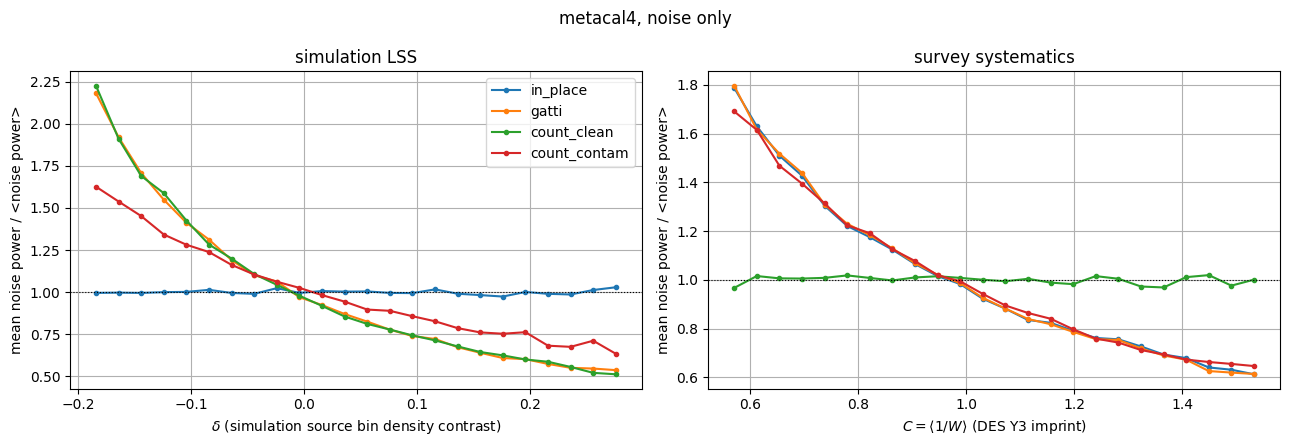


slope of the normalized noise power profile
arm                    simulation LSS    survey systematics
in_place                        0.000                -1.081
gatti                          -3.050                -1.097
count_clean                    -3.084                -0.011
count_contam                   -1.962                -1.031

against the contamination, as a fraction of the in_place slope (-1.081), which is the real survey:
  count_clean        1 %
  count_contam      95 %
  gatti            101 %


In [7]:
# real catalog footprint: pixels populated by the in_place noise, which sits on real galaxy positions
occ = noise_power(g["in_place"]) != 0
print(f"{occ.sum()} of {len(patch_pix)} base patch pixels hold real catalog galaxies ({100 * occ.mean():.1f}%)")

fields = {
    "simulation LSS": (delta[patch_pix, i_z][occ], "$\\delta$ (simulation source bin density contrast)"),
    "survey systematics": (contamination[patch_pix, i_z][occ], "$C = \\langle 1/W \\rangle$ (DES Y3 imprint)"),
}
slopes = {}

fig, ax = plt.subplots(figsize=(13, 4.5), ncols=len(fields))
for j, (field, (x, xlabel)) in enumerate(fields.items()):
    bins = np.linspace(*np.percentile(x, [1, 99]), 25)
    centres = 0.5 * (bins[:-1] + bins[1:])

    for name, gamma in g.items():
        profile, _, _ = binned_statistic(x, noise_power(gamma)[occ], statistic="mean", bins=bins)
        profile = profile / np.nanmean(profile)
        good = np.isfinite(profile)

        # slope of the normalized profile, i.e. the fractional change of the noise power per unit of x
        slopes[(field, name)] = np.polyfit(centres[good], profile[good], 1)[0]
        ax[j].plot(centres, profile, marker=".", label=name)

    ax[j].axhline(1.0, color="k", lw=0.8, ls=":")
    ax[j].set(xlabel=xlabel, ylabel="mean noise power / <noise power>", title=field)
    ax[j].grid(True, zorder=0)
ax[0].legend()
fig.suptitle(f"{metacal_bins[i_z]}, noise only")
fig.tight_layout()
plt.show()

print(f"\nslope of the normalized noise power profile\n{'arm':<15}" + "".join(f"{f:>22s}" for f in fields))
for name in g:
    print(f"{name:<15}" + "".join(f"{slopes[(f, name)]:>22.3f}" for f in fields))

truth = slopes[("survey systematics", "in_place")]
print(f"\nagainst the contamination, as a fraction of the in_place slope ({truth:.3f}), which is the real survey:")
for name in ("count_clean", "count_contam", "gatti"):
    print(f"  {name:<13} {100 * slopes[('survey systematics', name)] / truth:6.0f} %")

# Where this sits in the chain

- `bias_fit_desy3.ipynb` — where the per cosmology biases that both other notebooks read come from, and the pixel
  histogram statement of the contamination.
- `count_maps_desy3.ipynb` — the source counts themselves, contamination on and off, by eye.
- **this notebook** — whether the imprint survives the Poisson draw and the catalog resampling into the shear noise.

The slope of `count_contam` against $C$ is the number that carries over into the trained network: it is the amplitude
of a survey systematic that the summary statistics see in the noise, and the one a `count_clean` forward model was
missing entirely.